# Solo Enterprise agentgateway across two clusters, end to end: ingress, routing, rate limiting, cross-cluster failover, and MCP tool federation over HBONE

Two ambient kind clusters (`east-ag` + `west-ag`) are already peered over HBONE (the `agentgw-multi-cluster-kind` standup). This notebook drives the **exercises** on top of that platform. First the networking / traffic-control story on the agentgateway as an L7 gateway — **ingress**, **weighted (canary) routing**, **rate limiting**, and **locality-aware routing with cross-cluster failover**. Then the agentic story — federate **MCP tool servers** from both clusters behind **one** agentgateway endpoint and govern them with a single policy.

Every manifest is shown inline (`kubectl apply -f - <<'EOF' … EOF`) so you can talk through the YAML with the room.

> **Kernel:** this notebook runs on the **Bash** kernel. Pick it top-right (Select Kernel → Jupyter Kernel… → **Bash**). If it is missing or you get *"Failed to start the Kernel"*, run `./demo-scripts/notebook-kernel.sh` once, then reselect Bash.
>
> The standup (`scripts/quick.sh`) must already be green — this notebook only runs the exercises, not the setup.

## What you're running

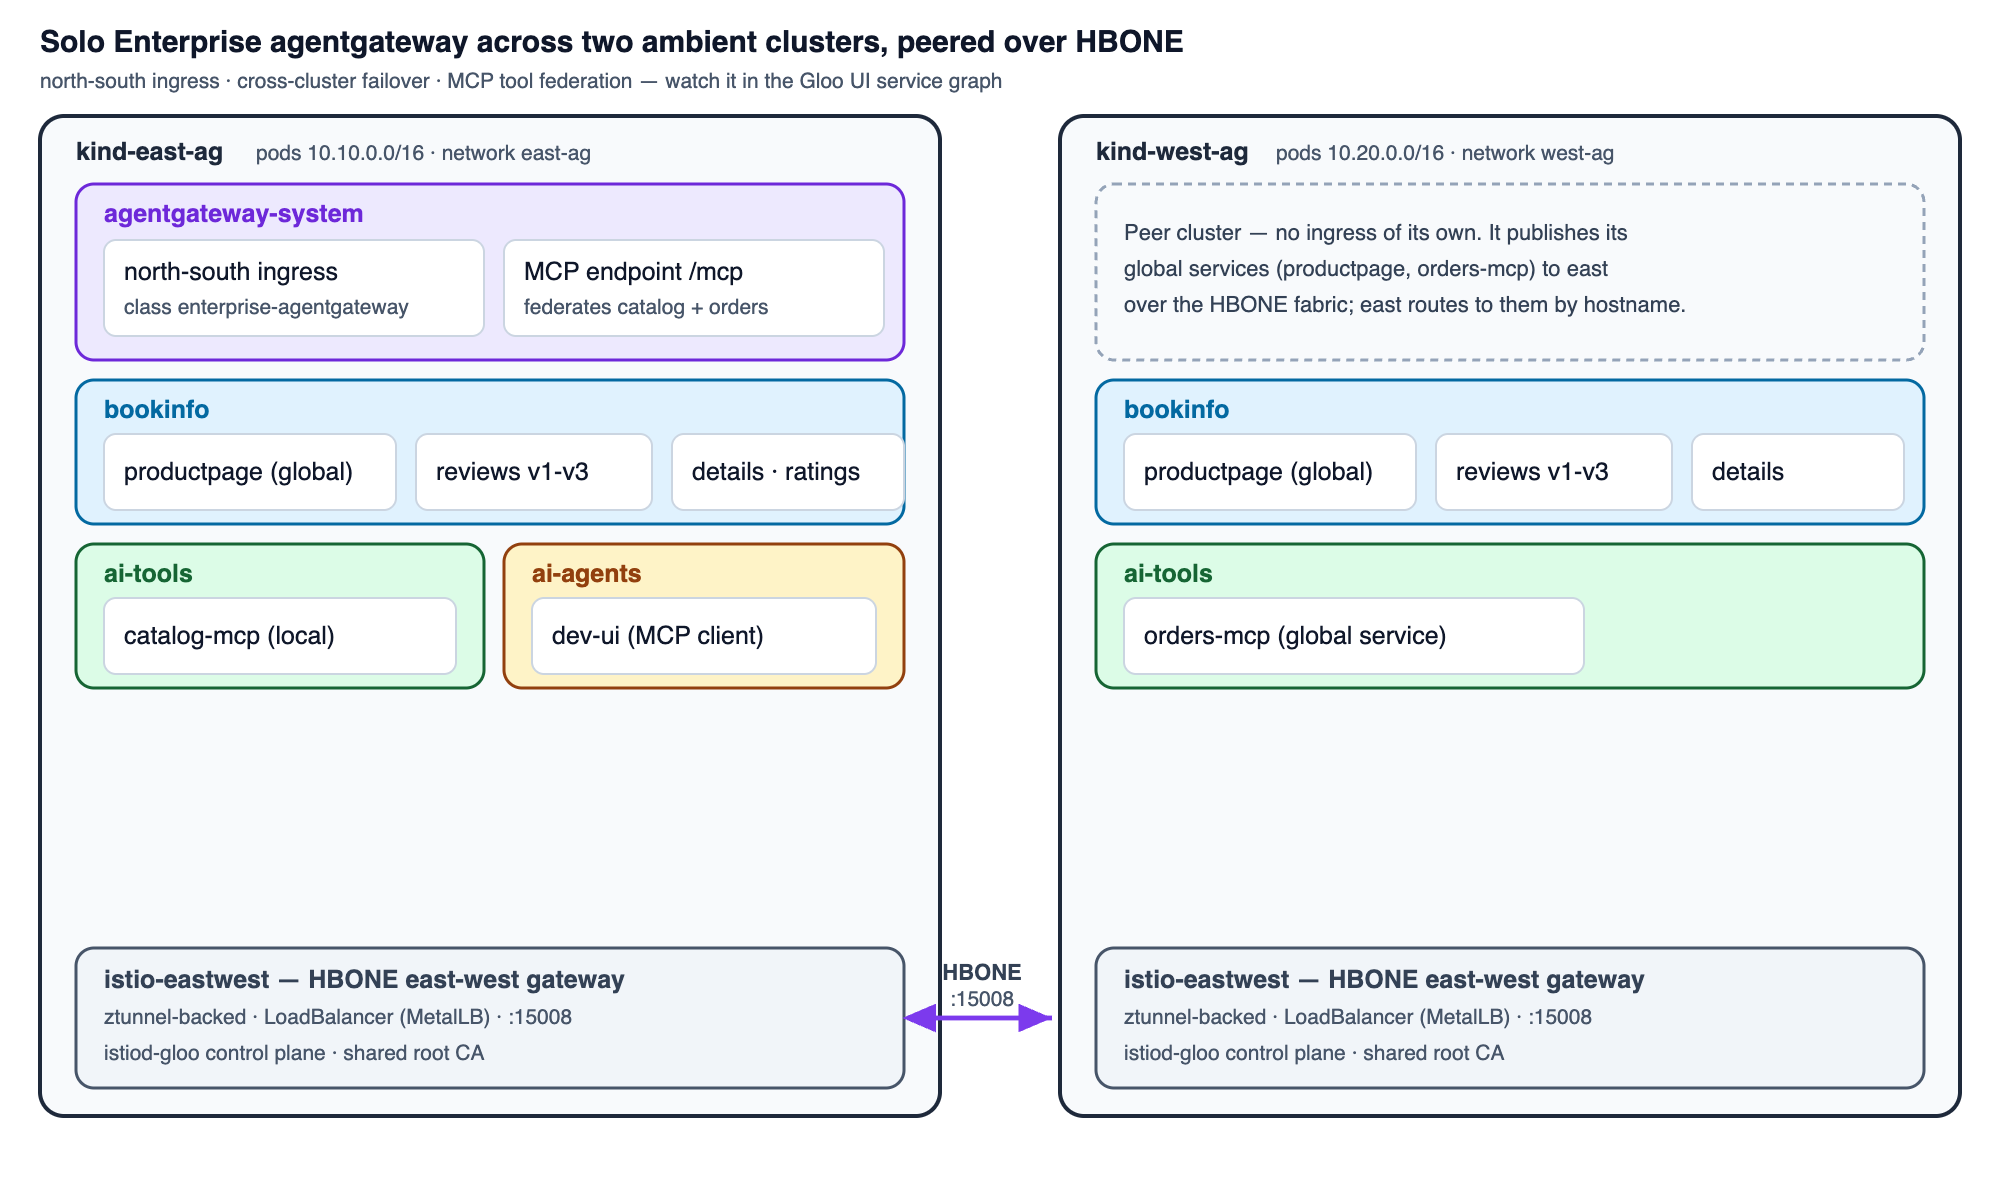

> One **agentgateway** on `east-ag` is the front door — it routes, weights and rate-limits north-south traffic to Bookinfo. Bookinfo runs on **both** clusters; making `reviews` a **global service** lets the mesh keep traffic local and fail over to **west** over HBONE when east is gone. Two MCP tool servers — `catalog-mcp` on east and `orders-mcp` on west — are federated behind a single agentgateway **`/mcp`** endpoint, and one `AgentgatewayPolicy` scopes which tools any caller sees. Watch the cross-cluster hops in the **Gloo UI service graph**.

## Open the consoles

Run this once and leave it in a terminal — it opens the Gloo UI (the multicluster service graph) and the Enterprise UI:

```bash
./demo-scripts/open-consoles.sh
```

| Console | URL | What it's for |
|---|---|---|
| **Gloo UI** | **http://localhost:8090** | service graph across **both** clusters — the cross-cluster hops show up here |
| Enterprise UI (agentgateway) | http://\<enterprise-ui LB\> | agentgateway dashboard + tracing (printed by `open-consoles.sh`) |

> Keep the Gloo UI open. As you run each exercise, refresh the **service graph** and watch traffic cross from `east-ag` to `west-ag`.

## Connect

`connect.sh` **exports** `CLUSTER1` (`kind-east-ag`) and `CLUSTER2` (`kind-west-ag`) and confirms the two clusters are peered. Because the Bash kernel keeps one shell across the whole notebook, every cell below can use `$CLUSTER1` / `$CLUSTER2`.

In [1]:
[ -d agentgw-multi-cluster-kind ] && cd agentgw-multi-cluster-kind || :
source demo-scripts/connect.sh
echo "CLUSTER1=$CLUSTER1   CLUSTER2=$CLUSTER2" 

east = kind-east-ag   west = kind-west-ag


✓ clusters peered over HBONE


CLUSTER1=kind-east-ag   CLUSTER2=kind-west-ag


## Deploy the workloads

Bookinfo runs on **both** clusters (for the ingress + failover demos); two MCP tool servers — `catalog-mcp` on east and `orders-mcp` on west — back the federation demo. Everything is applied inline so you can walk through each manifest.

### Bookinfo on both clusters

Create the `bookinfo` namespace on each cluster and give it the two labels the ambient mesh needs:
- `istio.io/dataplane-mode=ambient` — enrols every pod into the ambient mesh (ztunnel captures its traffic)
- `topology.istio.io/network=<cluster>` — tells istiod which cluster/network the pods belong to, so it can rewrite endpoints across clusters

In [2]:
for CTX in $CLUSTER1 $CLUSTER2; do
  kubectl --context $CTX create namespace bookinfo --dry-run=client -o yaml | kubectl --context $CTX apply -f -
  kubectl --context $CTX label namespace bookinfo \
    istio.io/dataplane-mode=ambient \
    topology.istio.io/network=${CTX#kind-} --overwrite
done

namespace/bookinfo created


namespace/bookinfo labeled


namespace/bookinfo created


namespace/bookinfo labeled


Deploy the standard upstream Bookinfo sample (productpage, details, reviews v1–v3, ratings) to both clusters:

In [3]:
BOOK=https://raw.githubusercontent.com/istio/istio/release-1.24/samples/bookinfo/platform/kube
for CTX in $CLUSTER1 $CLUSTER2; do
  kubectl --context $CTX -n bookinfo apply -f $BOOK/bookinfo.yaml
  kubectl --context $CTX -n bookinfo apply -f $BOOK/bookinfo-versions.yaml
done
kubectl --context $CLUSTER1 -n bookinfo wait --for=condition=Ready pod -l app=productpage --timeout=180s
kubectl --context $CLUSTER2 -n bookinfo wait --for=condition=Ready pod -l app=productpage --timeout=180s

service/details created


serviceaccount/bookinfo-details created


deployment.apps/details-v1 created


service/ratings created


serviceaccount/bookinfo-ratings created


...

service/productpage-v1 created


service/ratings-v1 created


service/details-v1 created


pod/productpage-v1-95fd4795b-b79q5 condition met


pod/productpage-v1-95fd4795b-6j4dn condition met


### MCP tool servers — `catalog-mcp` on east, `orders-mcp` on west

Both run the `@modelcontextprotocol/server-everything` reference MCP server over SSE. The important line is on the **west** `orders-mcp` Service: `solo.io/service-scope: global`. That is what publishes it as a cross-cluster **global service** so east can reach it over HBONE (the federation step points at its global VIP).

First the `ai-tools` namespace on both clusters (ambient + network label, same as bookinfo):

In [4]:
for CTX in $CLUSTER1 $CLUSTER2; do
  kubectl --context $CTX create namespace ai-tools --dry-run=client -o yaml | kubectl --context $CTX apply -f -
  kubectl --context $CTX label namespace ai-tools \
    istio.io/dataplane-mode=ambient \
    topology.istio.io/network=${CTX#kind-} --overwrite
done

namespace/ai-tools created


namespace/ai-tools labeled


namespace/ai-tools created


namespace/ai-tools labeled


`catalog-mcp` on **east** (local tool server):

In [5]:
kubectl --context $CLUSTER1 -n ai-tools apply -f - <<'EOF'
apiVersion: v1
kind: ServiceAccount
metadata: { name: catalog-mcp }
---
apiVersion: apps/v1
kind: Deployment
metadata: { name: catalog-mcp, labels: { app: catalog-mcp } }
spec:
  replicas: 1
  selector: { matchLabels: { app: catalog-mcp } }
  template:
    metadata: { labels: { app: catalog-mcp } }
    spec:
      serviceAccountName: catalog-mcp
      containers:
      - name: mcp
        image: node:20-alpine
        command: ["npx","-y","@modelcontextprotocol/server-everything","sse"]
        ports: [{ containerPort: 3001 }]
---
apiVersion: v1
kind: Service
metadata: { name: catalog-mcp, labels: { app: catalog-mcp } }
spec:
  selector: { app: catalog-mcp }
  ports: [{ name: http, port: 3001, targetPort: 3001, appProtocol: http }]
EOF

serviceaccount/catalog-mcp created


deployment.apps/catalog-mcp created


service/catalog-mcp created


`orders-mcp` on **west** — note `solo.io/service-scope: global` on the Service:

In [6]:
kubectl --context $CLUSTER2 -n ai-tools apply -f - <<'EOF'
apiVersion: v1
kind: ServiceAccount
metadata: { name: orders-mcp }
---
apiVersion: apps/v1
kind: Deployment
metadata: { name: orders-mcp, labels: { app: orders-mcp } }
spec:
  replicas: 1
  selector: { matchLabels: { app: orders-mcp } }
  template:
    metadata: { labels: { app: orders-mcp } }
    spec:
      serviceAccountName: orders-mcp
      containers:
      - name: mcp
        image: node:20-alpine
        command: ["npx","-y","@modelcontextprotocol/server-everything","sse"]
        ports: [{ containerPort: 3001 }]
---
apiVersion: v1
kind: Service
metadata:
  name: orders-mcp
  labels:
    app: orders-mcp
    solo.io/service-scope: global        # <-- publishes it cross-cluster over HBONE
spec:
  selector: { app: orders-mcp }
  ports: [{ name: http, port: 3001, targetPort: 3001, appProtocol: http }]
EOF

serviceaccount/orders-mcp created


deployment.apps/orders-mcp created


service/orders-mcp created


A `dev-ui` caller pod on **east** (an in-mesh MCP client we'll use for the failover curl and to show identity):

In [7]:
kubectl --context $CLUSTER1 create namespace ai-agents --dry-run=client -o yaml | kubectl --context $CLUSTER1 apply -f -
kubectl --context $CLUSTER1 label namespace ai-agents \
  istio.io/dataplane-mode=ambient \
  topology.istio.io/network=${CLUSTER1#kind-} --overwrite

kubectl --context $CLUSTER1 -n ai-agents apply -f - <<'EOF'
apiVersion: v1
kind: ServiceAccount
metadata: { name: dev-ui }
---
apiVersion: apps/v1
kind: Deployment
metadata: { name: dev-ui, labels: { app: dev-ui } }
spec:
  replicas: 1
  selector: { matchLabels: { app: dev-ui } }
  template:
    metadata: { labels: { app: dev-ui } }
    spec:
      serviceAccountName: dev-ui
      containers: [{ name: curl, image: curlimages/curl:8.5.0, command: ["sleep","infinity"] }]
EOF

namespace/ai-agents created


namespace/ai-agents labeled


serviceaccount/dev-ui created


deployment.apps/dev-ui created


Wait for the tool servers and caller to be Ready (the first `npx` pull can take ~90s):

In [8]:
kubectl --context $CLUSTER1 -n ai-tools  wait --for=condition=Ready pod --all --timeout=240s
kubectl --context $CLUSTER2 -n ai-tools  wait --for=condition=Ready pod --all --timeout=240s
kubectl --context $CLUSTER1 -n ai-agents wait --for=condition=Ready pod --all --timeout=120s

pod/catalog-mcp-7645f45c4-jkkk7 condition met


pod/orders-mcp-869f877c46-25n5x condition met


pod/dev-ui-65bdd48445-mq672 condition met


## 1. Reach a service through the agentgateway ingress

Expose Bookinfo's `productpage` through an agentgateway `Gateway` (class `enterprise-agentgateway`) and an `HTTPRoute`. This is the north-south front door — one agentgateway data plane on `east-ag`, reached on a MetalLB LoadBalancer IP.

In [9]:
kubectl --context $CLUSTER1 -n bookinfo apply -f - <<'EOF'
apiVersion: gateway.networking.k8s.io/v1
kind: Gateway
metadata: { name: bookinfo-gateway, namespace: bookinfo }
spec:
  gatewayClassName: enterprise-agentgateway
  listeners:
  - { name: http, port: 8080, protocol: HTTP, allowedRoutes: { namespaces: { from: Same } } }
---
apiVersion: gateway.networking.k8s.io/v1
kind: HTTPRoute
metadata: { name: productpage, namespace: bookinfo }
spec:
  parentRefs: [{ name: bookinfo-gateway }]
  rules:
  - backendRefs: [{ name: productpage, port: 9080 }]
EOF

kubectl --context $CLUSTER1 -n bookinfo wait --for=condition=Programmed gateway/bookinfo-gateway --timeout=90s
kubectl --context $CLUSTER1 -n bookinfo wait --for=condition=Ready \
  pod -l gateway.networking.k8s.io/gateway-name=bookinfo-gateway --timeout=120s

gateway.gateway.networking.k8s.io/bookinfo-gateway created


httproute.gateway.networking.k8s.io/productpage created


gateway.gateway.networking.k8s.io/bookinfo-gateway condition met


pod/bookinfo-gateway-6bbc46767d-twc67 condition met


In [10]:
GW=$(kubectl --context $CLUSTER1 -n bookinfo get gateway bookinfo-gateway -o jsonpath='{.status.addresses[0].value}')
echo "agentgateway ingress: http://$GW:8080/productpage"
curl -s -o /dev/null -w "  HTTP %{http_code}\n" "http://$GW:8080/productpage"    # -> HTTP 200

agentgateway ingress: http://192.168.97.105:8080/productpage


  HTTP 200


**In the Gloo UI** (http://localhost:8090) open the **Graph**, cluster `east-ag`, namespace `bookinfo` — the `bookinfo-gateway` now fronts `productpage`. Everything so far is single-cluster; the next exercise makes it span clusters.

## 2. Split traffic with weighted (canary) routing

The agentgateway is a full L7 gateway, so an `HTTPRoute` can weight backends. Send 80% of `/reviews` to `reviews-v1` and 20% to `reviews-v2` — the split is enforced at the gateway, no app change.

In [11]:
kubectl --context $CLUSTER1 -n bookinfo apply -f - <<'EOF'
apiVersion: gateway.networking.k8s.io/v1
kind: HTTPRoute
metadata: { name: reviews-canary, namespace: bookinfo }
spec:
  parentRefs: [{ name: bookinfo-gateway }]
  rules:
  - matches: [{ path: { type: PathPrefix, value: /reviews } }]
    backendRefs:
    - { name: reviews-v1, port: 9080, weight: 80 }
    - { name: reviews-v2, port: 9080, weight: 20 }
EOF
sleep 3

httproute.gateway.networking.k8s.io/reviews-canary created


In [12]:
# 20 calls through the gateway -- count which version served (~80/20)
GW=$(kubectl --context $CLUSTER1 -n bookinfo get gateway bookinfo-gateway -o jsonpath='{.status.addresses[0].value}')
for i in $(seq 1 20); do curl -s "http://$GW:8080/reviews/0" | grep -oE 'reviews-v[0-9]'; done | sort | uniq -c

  14 reviews-v1


   6 reviews-v2


Shift the weights (e.g. 50/50, or 0/100 to cut over) and re-run — the split follows immediately. This is your canary / blue-green control.

## 3. Rate-limit a route

Attach a **local** rate limit to the `productpage` route: 2 requests/second, anything above returns `429`. "Local" means per-gateway — each gateway instance enforces its own budget (for a single budget shared across both clusters you point `rateLimit.global` at a shared rate-limit service).

In [13]:
kubectl --context $CLUSTER1 -n bookinfo apply -f - <<'EOF'
apiVersion: agentgateway.dev/v1alpha1
kind: AgentgatewayPolicy
metadata: { name: ingress-ratelimit, namespace: bookinfo }
spec:
  targetRefs:
  - { group: gateway.networking.k8s.io, kind: HTTPRoute, name: productpage }
  traffic:
    rateLimit:
      local:
      - requests: 2
        unit: Seconds
EOF
sleep 4

agentgatewaypolicy.agentgateway.dev/ingress-ratelimit created


In [14]:
# 8 quick requests -- first 2 pass (200), the rest are limited (429)
GW=$(kubectl --context $CLUSTER1 -n bookinfo get gateway bookinfo-gateway -o jsonpath='{.status.addresses[0].value}')
for i in $(seq 1 8); do curl -s -o /dev/null -w "%{http_code} " "http://$GW:8080/productpage"; done; echo

200 200 429 429 429 429 429 429 


## 4. Locality-aware routing and cross-cluster failover — over HBONE

Label `reviews` a **global** service on both clusters. Solo Istio publishes a cluster-wide hostname `reviews.bookinfo.mesh.internal` whose endpoints span **both** clusters, and the mesh prefers **local** endpoints — spilling to the peer only when local is gone. This is the resilience story: same hostname, traffic stays local until it can't.

In [15]:
for CTX in $CLUSTER1 $CLUSTER2; do
  kubectl --context $CTX -n bookinfo label svc reviews solo.io/service-scope=global --overwrite
done
sleep 8
istioctl --context $CLUSTER1 multicluster check 2>/dev/null | grep -i "Shared Services"   # -> globally shared service(s)

service/reviews labeled


service/reviews labeled


✅ Shared Services Check: 3 globally shared service(s)


In [16]:
# Both clusters up: an east caller stays LOCAL (all pods are east's)
echo "east reviews pod: $(kubectl --context $CLUSTER1 -n bookinfo get pod -l app=reviews,version=v1 -o jsonpath='{.items[0].metadata.name}')"
echo "west reviews pod: $(kubectl --context $CLUSTER2 -n bookinfo get pod -l app=reviews,version=v1 -o jsonpath='{.items[0].metadata.name}')"
echo "--- 10 calls to the GLOBAL hostname from east (expect only east pods) ---"
for i in $(seq 1 10); do
  kubectl --context $CLUSTER1 -n ai-agents exec deploy/dev-ui -- \
    curl -s -m 6 http://reviews.bookinfo.mesh.internal:9080/reviews/0 2>/dev/null | grep -oE '"podname": "[^"]+"'
done | sort | uniq -c

east reviews pod: reviews-v1-7d457568f-bqvj6


west reviews pod: reviews-v1-7d457568f-zks97


--- 10 calls to the GLOBAL hostname from east (expect only east pods) ---


   5 "podname": "reviews-v1-7d457568f-bqvj6"


   1 "podname": "reviews-v2-66c97ddb57-fbdwf"


   4 "podname": "reviews-v3-586d476db5-ccjk8"


In [17]:
# Take east's reviews away entirely
for v in v1 v2 v3; do kubectl --context $CLUSTER1 -n bookinfo scale deploy reviews-$v --replicas=0; done
kubectl --context $CLUSTER1 -n bookinfo wait --for=delete pod -l app=reviews --timeout=40s

# Same hostname, no client change -- now every call is served by WEST over HBONE
echo "--- 6 calls to the GLOBAL hostname from east (expect west pods now) ---"
for i in $(seq 1 6); do
  kubectl --context $CLUSTER1 -n ai-agents exec deploy/dev-ui -- \
    curl -s -m 6 http://reviews.bookinfo.mesh.internal:9080/reviews/0 2>/dev/null | grep -oE '"podname": "[^"]+"'
done | sort | uniq -c

deployment.apps/reviews-v1 scaled


deployment.apps/reviews-v2 scaled


deployment.apps/reviews-v3 scaled


pod/reviews-v1-7d457568f-bqvj6 condition met


pod/reviews-v2-66c97ddb57-fbdwf condition met


pod/reviews-v3-586d476db5-ccjk8 condition met


--- 6 calls to the GLOBAL hostname from east (expect west pods now) ---


   1 "podname": "reviews-v1-7d457568f-zks97"


   1 "podname": "reviews-v2-66c97ddb57-jndmd"


   4 "podname": "reviews-v3-586d476db5-lmlsp"


In [18]:
# Restore east's reviews
for v in v1 v2 v3; do kubectl --context $CLUSTER1 -n bookinfo scale deploy reviews-$v --replicas=1; done
kubectl --context $CLUSTER1 -n bookinfo wait --for=condition=Ready pod -l app=reviews --timeout=90s

deployment.apps/reviews-v1 scaled


deployment.apps/reviews-v2 scaled


deployment.apps/reviews-v3 scaled


pod/reviews-v1-7d457568f-48jrn condition met


pod/reviews-v2-66c97ddb57-mq7xh condition met


pod/reviews-v3-586d476db5-cwk7j condition met


**In the Gloo UI** service graph you'll see the calls stay inside `east-ag` while it's healthy, then cross into `west-ag` over the HBONE east-west gateway once east's `reviews` is scaled to zero. Prefer-local, fail-to-remote — one global hostname, no client change.

## 5. Federate MCP tool servers from both clusters behind one endpoint

`catalog-mcp` runs on **east**, `orders-mcp` runs on **west** (the global service you deployed above). One agentgateway `AgentgatewayBackend` federates both into a single MCP `/mcp` endpoint. East reaches the west server over HBONE via its global VIP, so a single `tools/list` returns tools from **both** clusters, names prefixed by target.

In [19]:
# The west orders-mcp is a global service; grab the VIP east routes to it on
VIP=$(istioctl --context $CLUSTER1 ztunnel-config service 2>/dev/null | awk '/orders-mcp/{print $3}' | cut -d, -f1)
echo "west orders-mcp reachable from east at: $VIP:3001 (over HBONE)"

kubectl --context $CLUSTER1 -n ai-tools apply -f - <<EOF
apiVersion: agentgateway.dev/v1alpha1
kind: AgentgatewayBackend
metadata: { name: mcp-be }
spec:
  mcp:
    sessionRouting: Stateless          # each MCP call is one request -- no session handshake
    targets:
    - { name: catalog, static: { host: catalog-mcp.ai-tools.svc.cluster.local, port: 3001, protocol: SSE } }
    - { name: orders,  static: { host: "$VIP", port: 3001, protocol: SSE } }   # west, over HBONE
EOF

kubectl --context $CLUSTER1 -n ai-tools apply -f - <<'EOF'
apiVersion: gateway.networking.k8s.io/v1
kind: Gateway
metadata: { name: mcp-gateway, namespace: ai-tools }
spec:
  gatewayClassName: enterprise-agentgateway
  listeners: [{ name: http, port: 8080, protocol: HTTP, allowedRoutes: { namespaces: { from: Same } } }]
---
apiVersion: gateway.networking.k8s.io/v1
kind: HTTPRoute
metadata: { name: mcp-route, namespace: ai-tools }
spec:
  parentRefs: [{ name: mcp-gateway }]
  rules:
  - backendRefs: [{ group: agentgateway.dev, kind: AgentgatewayBackend, name: mcp-be }]
EOF

kubectl --context $CLUSTER1 -n ai-tools wait --for=condition=Programmed gateway/mcp-gateway --timeout=90s
kubectl --context $CLUSTER1 -n ai-tools wait --for=condition=Ready \
  pod -l gateway.networking.k8s.io/gateway-name=mcp-gateway --timeout=120s

west orders-mcp reachable from east at: 240.240.0.20:3001 (over HBONE)


agentgatewaybackend.agentgateway.dev/mcp-be created


gateway.gateway.networking.k8s.io/mcp-gateway created


httproute.gateway.networking.k8s.io/mcp-route created


gateway.gateway.networking.k8s.io/mcp-gateway condition met


pod/mcp-gateway-6b785694fb-mkwgc condition met


The MCP endpoint speaks **JSON-RPC over HTTP**. Because the backend is `Stateless`, one `POST` lists the tools — no session handshake. The response comes back as a Server-Sent-Events frame, so we strip the leading `data:`. `tools/list` returns tools from **both** clusters (`catalog_*` = east, `orders_*` = west):

In [20]:
GW=$(kubectl --context $CLUSTER1 -n ai-tools get gateway mcp-gateway -o jsonpath='{.status.addresses[0].value}')

curl -s -X POST "http://$GW:8080/mcp" \
  -H "Content-Type: application/json" -H "Accept: application/json,text/event-stream" \
  -d '{"jsonrpc":"2.0","id":1,"method":"tools/list"}' \
  | sed 's/^data: //' | grep -oE '"name":"[^"]+"'

"name":"catalog_echo"


"name":"catalog_get-annotated-message"


"name":"catalog_get-env"


"name":"catalog_get-resource-links"


"name":"catalog_get-resource-reference"


...

"name":"orders_gzip-file-as-resource"


"name":"orders_toggle-simulated-logging"


"name":"orders_toggle-subscriber-updates"


"name":"orders_trigger-long-running-operation"


"name":"orders_simulate-research-query"


In [21]:
# Call a tool that runs on WEST (over HBONE), and one that runs locally on EAST.
# Each is a single JSON-RPC POST to the same /mcp endpoint.
GW=$(kubectl --context $CLUSTER1 -n ai-tools get gateway mcp-gateway -o jsonpath='{.status.addresses[0].value}')
call() { curl -s -X POST "http://$GW:8080/mcp" -H "Content-Type: application/json" -H "Accept: application/json,text/event-stream" -d "$1" | sed 's/^data: //'; }

echo "orders_echo    (west): $(call '{"jsonrpc":"2.0","id":2,"method":"tools/call","params":{"name":"orders_echo","arguments":{"message":"hi from east"}}}' | grep -oE '"text":"[^"]*"')"
echo "catalog_get-sum (east): $(call '{"jsonrpc":"2.0","id":3,"method":"tools/call","params":{"name":"catalog_get-sum","arguments":{"a":40,"b":2}}}' | grep -oE '"text":"[^"]*"')" 

orders_echo    (west): "text":"Echo: hi from east"


catalog_get-sum (east): "text":"The sum of 40 and 2 is 42."


One agentgateway endpoint, tools drawn from **two clusters**. The `orders_*` calls execute on `west-ag` and return over HBONE; the caller never knew there were two clusters.

## 6. Govern the federated tools with one policy

An `AgentgatewayPolicy` with `action: Allow` is deny-by-default: only tools matching the CEL rules survive `tools/list`, and blocked tools can't be called — across **both** clusters, from one policy.

In [22]:
kubectl --context $CLUSTER1 -n ai-tools apply -f - <<'EOF'
apiVersion: agentgateway.dev/v1alpha1
kind: AgentgatewayPolicy
metadata: { name: mcp-tool-allowlist, namespace: ai-tools }
spec:
  targetRefs: [{ group: agentgateway.dev, kind: AgentgatewayBackend, name: mcp-be }]
  backend:
    mcp:
      authorization:
        action: Allow            # deny-by-default: only matching tools pass
        policy:
          matchExpressions:
          - 'mcp.tool.name == "echo"'
          - 'mcp.tool.name == "get-sum"'
EOF
sleep 3

agentgatewaypolicy.agentgateway.dev/mcp-tool-allowlist created


In [23]:
GW=$(kubectl --context $CLUSTER1 -n ai-tools get gateway mcp-gateway -o jsonpath='{.status.addresses[0].value}')
call() { curl -s -X POST "http://$GW:8080/mcp" -H "Content-Type: application/json" -H "Accept: application/json,text/event-stream" -d "$1" | sed 's/^data: //'; }

# The federated list collapses to the allowed tools on BOTH targets
echo "--- tools/list after the policy ---"
call '{"jsonrpc":"2.0","id":1,"method":"tools/list"}' | grep -oE '"name":"[^"]+"'

# A blocked tool is filtered out entirely -- it can't even be called
echo "--- call a blocked tool ---"
echo "orders_get-env -> $(call '{"jsonrpc":"2.0","id":2,"method":"tools/call","params":{"name":"orders_get-env","arguments":{}}}' | grep -oE '"(message|text)":"[^"]*"' | head -1)" 

--- tools/list after the policy ---


"name":"catalog_echo"


"name":"catalog_get-sum"


"name":"orders_echo"


"name":"orders_get-sum"


--- call a blocked tool ---


orders_get-env -> "message":"Unknown tool: orders_get-env"


That's the multicluster story end to end: one agentgateway ingress, cross-cluster failover over HBONE, MCP tools federated from two clusters behind one endpoint, and a single policy governing them all — with the traffic visible in the Gloo UI service graph.

## Reset

Remove the exercise workloads (the platform standup stays up):

```bash
./demo-scripts/reset.sh
```